# Single LIF Example


> **Note:** This notebook currently runs against synthetic data captured with Blackchirp 2.0 against its built-in virtual hardware. A refresh using real instrument data is planned and will land here without any change to the surrounding narrative or API surface.

This notebook walks through the LIF surface of the Blackchirp Python module against a small Blackchirp 2.0 fixture shipped with the source tree (`python/example-data/v2-lif-ref/`). It is a partial 6 × 6 (laser × delay) scan with a reference channel enabled. The acquisition was stopped before the full grid completed, so several scan points are missing — useful for exercising the missing-point handling on `BCLIF.delay_slice`, `BCLIF.laser_slice`, and `BCLIF.image`.

The package is on PyPI (`pip install blackchirp`); the recommended import style is `from blackchirp import *`. Matplotlib is imported for visualization but is **not** a runtime dependency of the `blackchirp` package itself.

In [1]:
from blackchirp import *
from matplotlib import pyplot as plt
import numpy as np

## Loading and Inspecting an Experiment

Pass `BCExperiment` the path to the experiment folder. When the folder contains a `lif/` subdirectory, a `BCLIF` is constructed and exposed as `exp.lif`.

In [2]:
ls example-data/v2-lif-ref/

auxdata.csv   header.csv  log.csv         version.csv
hardware.csv  lif/        objectives.csv


In [3]:
exp = BCExperiment('./example-data/v2-lif-ref/')
exp.lif

`BCLIF` reads the scan-axis configuration from the `LifConfig` rows in `header.csv` at construction time. The `delay_axis` and `laser_axis` accessors return the full sample arrays together with their units strings:

In [4]:
delays, delay_units = exp.lif.delay_axis()
lasers, laser_units = exp.lif.laser_axis()
delays, delay_units, lasers, laser_units

(array([200., 210., 220., 230., 240., 250.]),
 'μs',
 array([280., 281., 282., 283., 284., 285.]),
 'nm')

The `lifparams` attribute is the index of acquired scan points. Only rows present in `lifparams.csv` were actually written to disk; any `(lIndex, dIndex)` combination not in this table was never acquired.

In [5]:
exp.lif.lifparams

,lIndex,dIndex,shots,lifsize,refsize,spacing,lifymult,refymult
0,0,0,20,10000,10000,8.000000e-10,0.001953,0.000391
1,1,0,20,10000,10000,8.000000e-10,0.001953,0.000391
2,2,0,20,10000,10000,8.000000e-10,0.001953,0.000391
3,0,1,20,10000,10000,8.000000e-10,0.001953,0.000391
4,1,1,20,10000,10000,8.000000e-10,0.001953,0.000391
5,2,1,6,10000,10000,8.000000e-10,0.001953,0.000391
6,0,2,20,10000,10000,8.000000e-10,0.001953,0.000391
7,1,2,20,10000,10000,8.000000e-10,0.001953,0.000391
8,0,3,20,10000,10000,8.000000e-10,0.001953,0.000391
9,1,3,20,10000,10000,8.000000e-10,0.001953,0.000391


The default integration gates and waveform-filter settings live in `lif/processing.csv` and are exposed as the `proc` dictionary. These are the same controls that the LIF tab in the Blackchirp GUI exposes.

In [6]:
exp.lif.proc

{'LifGateEndPoint': 1421,
 'LifGateStartPoint': 500,
 'LowPassAlpha': 0.0,
 'RefGateEndPoint': 300,
 'RefGateStartPoint': 100,
 'SavGolEnabled': False,
 'SavGolPoly': 3,
 'SavGolWindow': 11}

## Inspecting a Single Trace

Per-point traces are loaded lazily via `BCLIF.get_trace(l_index, d_index)`. For this fixture, `(l=0, d=0)` is the lower-left corner of the scan. The returned `BCLifTrace` exposes the LIF waveform (`lif()`), the optional reference waveform (`ref()`), and the time axis (`x()` or `xy()`).

In [7]:
trace = exp.lif.get_trace(l_index=0, d_index=0)
trace.shots, trace.lifsize, trace.refsize, trace.spacing

(20, 10000, 10000, 8e-10)

Plot the raw LIF and reference channels side-by-side. The integration gates from `processing.csv` are overlaid as shaded regions to show where `BCLifTrace.integrate` will sum:

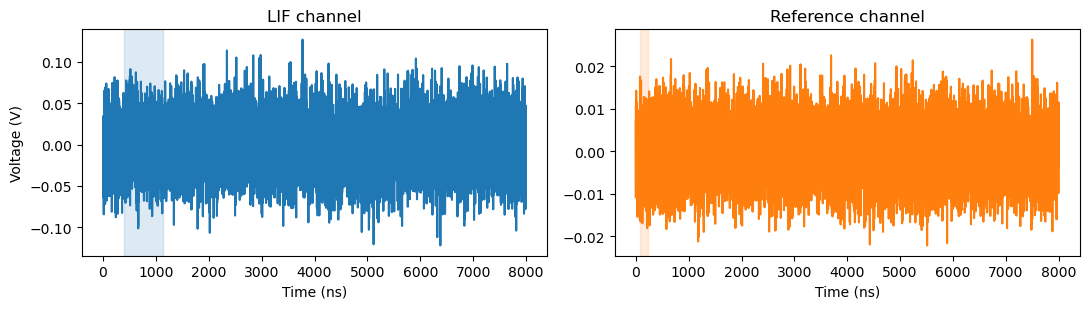

In [8]:
x_ns = trace.x(units='ns')
lif_y = trace.lif()
ref_y = trace.ref()

lif_gate = (exp.lif.proc['LifGateStartPoint'], exp.lif.proc['LifGateEndPoint'])
ref_gate = (exp.lif.proc['RefGateStartPoint'], exp.lif.proc['RefGateEndPoint'])

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(11, 3.2), sharey=False)
ax_l.plot(x_ns, lif_y, color='C0')
ax_l.axvspan(x_ns[lif_gate[0]], x_ns[lif_gate[1]], color='C0', alpha=0.15)
ax_l.set_title('LIF channel')
ax_l.set_xlabel('Time (ns)')
ax_l.set_ylabel('Voltage (V)')
ax_r.plot(x_ns, ref_y, color='C1')
ax_r.axvspan(x_ns[ref_gate[0]], x_ns[ref_gate[1]], color='C1', alpha=0.15)
ax_r.set_title('Reference channel')
ax_r.set_xlabel('Time (ns)')
fig.tight_layout()

## Smoothing and Integration

`BCLifTrace.smooth` applies the IIR low-pass filter followed by the Savitzky-Golay smoother that the GUI uses. Both stages follow `processing.csv` by default; pass `low_pass=...`, `savgol=...`, or any of the named parameter overrides to deviate. To see the effect of an aggressive Savitzky-Golay window, force `savgol=True` with a wider window:

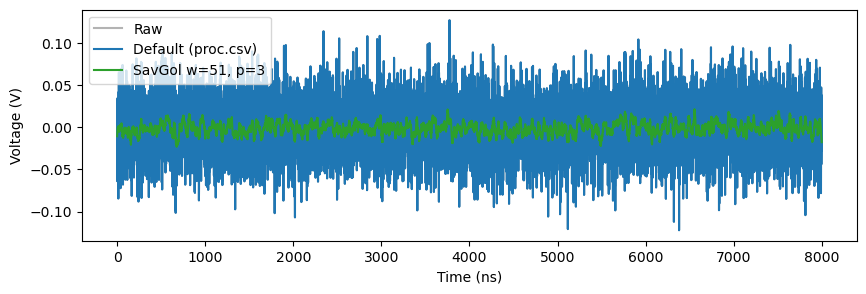

In [9]:
raw = trace.lif()
smoothed_default = trace.smooth()  # follows processing.csv
smoothed_strong = trace.smooth(savgol=True, savgol_window=51, savgol_poly=3)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(x_ns, raw, color='0.7', label='Raw')
ax.plot(x_ns, smoothed_default, color='C0', label='Default (proc.csv)')
ax.plot(x_ns, smoothed_strong, color='C2', label='SavGol w=51, p=3')
ax.set_xlabel('Time (ns)')
ax.set_ylabel('Voltage (V)')
ax.legend()

`BCLifTrace.integrate` runs the same filter chain and then takes a trapezoidal sum **in sample-index space** between the LIF gate endpoints. With a reference channel present (as here), the return value is the dimensionless ratio of LIF integral over reference integral. To get the unratioed LIF integral instead, override the reference gate so it collapses to zero (or use the `v2-lif-noref/` fixture, which has no reference channel at all).

In [10]:
integral_default = trace.integrate()
integral_wide_lif = trace.integrate(lif_start=400, lif_end=1600)
integral_default, integral_wide_lif

(7.926510330398397, 11.893470490802894)

## Aggregating Helpers

`BCLIF.delay_slice(l_index)` integrates every present trace at one laser index and returns `(delay_axis, integrals)` arrays sized against the full delay axis. Missing scan points are filled with `np.nan` by default. For `l=2` in this fixture, only two delay points were acquired — the rest come back as NaN:

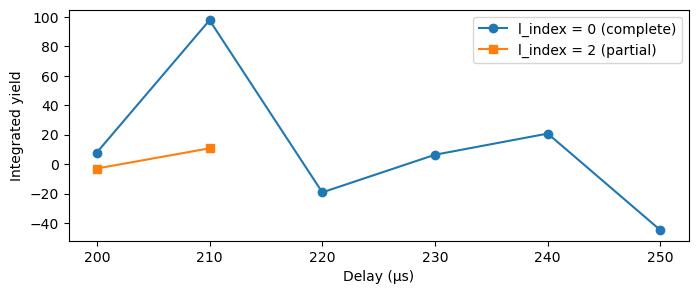

In [11]:
delays_axis, integrals_l0 = exp.lif.delay_slice(l_index=0)
delays_axis, integrals_l2 = exp.lif.delay_slice(l_index=2)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(delays_axis, integrals_l0, marker='o', label='l_index = 0 (complete)')
ax.plot(delays_axis, integrals_l2, marker='s', label='l_index = 2 (partial)')
ax.set_xlabel(f'Delay ({delay_units})')
ax.set_ylabel('Integrated yield')
ax.legend()

Pass `fill=0.0` (or any other numeric value) to substitute the missing positions with that value rather than NaN. This is convenient when downstream code (or matplotlib) does not handle NaN gracefully:

In [12]:
_, integrals_l2_zero = exp.lif.delay_slice(l_index=2, fill=0.0)
integrals_l2_zero

array([-2.92994452, 10.77452153,  0.        ,  0.        ,  0.        ,
        0.        ])

`BCLIF.laser_slice(d_index)` is the symmetric helper across the laser axis. Override the gate positions per call to integrate over a different sample range without modifying `processing.csv`:

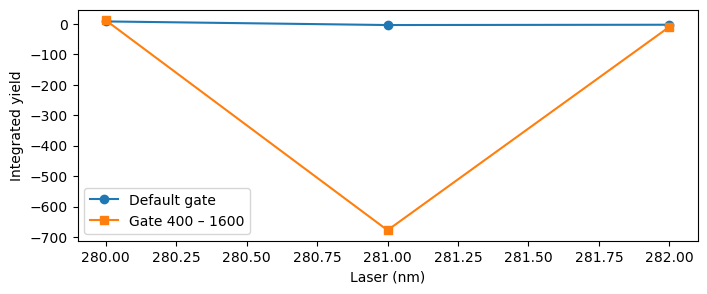

In [13]:
lasers_axis, integrals_d0 = exp.lif.laser_slice(d_index=0)
_, integrals_d0_wide = exp.lif.laser_slice(d_index=0, lif_start=400, lif_end=1600)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(lasers_axis, integrals_d0, marker='o', label='Default gate')
ax.plot(lasers_axis, integrals_d0_wide, marker='s', label='Gate 400 – 1600')
ax.set_xlabel(f'Laser ({laser_units})')
ax.set_ylabel('Integrated yield')
ax.legend()

## Full 2D Image

`BCLIF.image()` integrates every present scan point into a 2-D array of shape `(delay_points, laser_points)`. The same `fill=` keyword controls the missing-point value. Plot both forms side-by-side to make the difference visible: NaN cells are drawn as the colormap's background by `pcolormesh`, while `fill=0.0` makes them part of the color range.

In [14]:
delays_img, lasers_img, image_nan = exp.lif.image()
_, _, image_zero = exp.lif.image(fill=0.0)
image_nan.shape, image_zero.shape

((6, 6), (6, 6))

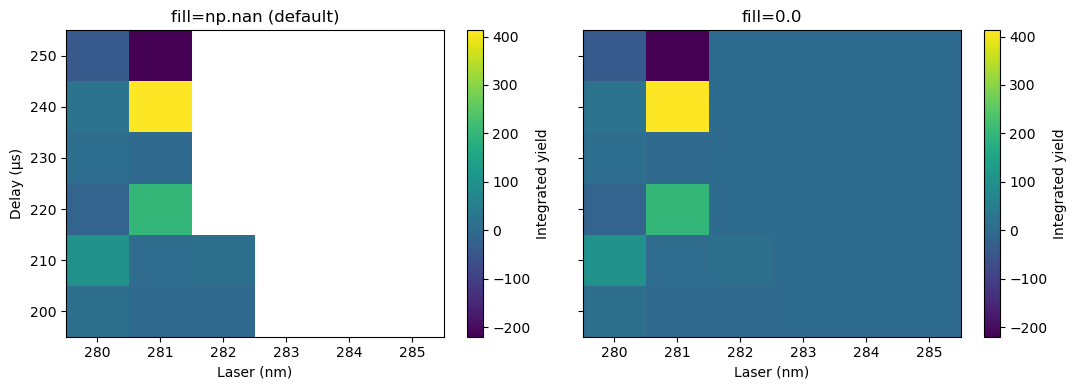

In [15]:
fig, (ax_n, ax_z) = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
mesh_n = ax_n.pcolormesh(lasers_img, delays_img, image_nan, shading='nearest', cmap='viridis')
ax_n.set_title('fill=np.nan (default)')
ax_n.set_xlabel(f'Laser ({laser_units})')
ax_n.set_ylabel(f'Delay ({delay_units})')
fig.colorbar(mesh_n, ax=ax_n, label='Integrated yield')
mesh_z = ax_z.pcolormesh(lasers_img, delays_img, image_zero, shading='nearest', cmap='viridis')
ax_z.set_title('fill=0.0')
ax_z.set_xlabel(f'Laser ({laser_units})')
fig.colorbar(mesh_z, ax=ax_z, label='Integrated yield')
fig.tight_layout()

`pcolormesh` works well when the scan grid is at least 2 × 2. When one of the scan axes has only a single point, `shading='flat'` (the default) collapses the entire row or column to zero quads and the plot appears empty. `shading='nearest'` (used above) handles that case but still requires you to pass the axis arrays as cell centers.

An alternative is `imshow`, which always draws one pixel per array element regardless of axis length. It assumes a uniformly spaced grid — which the LIF delay and laser axes always are — and takes the data extent through the `extent=` keyword. `aspect='auto'` is essential, otherwise a `(1, N)` image is rendered as a sliver one pixel tall; `origin='lower'` flips the y-axis so increasing delay points upward as expected.

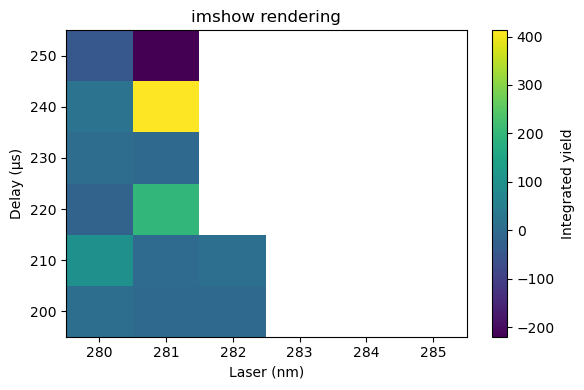

In [16]:
delay_step = exp.lif.delay_step
laser_step = exp.lif.laser_step
extent = (
    lasers_img[0] - laser_step / 2,
    lasers_img[-1] + laser_step / 2,
    delays_img[0] - delay_step / 2,
    delays_img[-1] + delay_step / 2,
)

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(
    image_nan,
    extent=extent,
    origin='lower',
    aspect='auto',
    interpolation='nearest',
    cmap='viridis',
)
ax.set_title('imshow rendering')
ax.set_xlabel(f'Laser ({laser_units})')
ax.set_ylabel(f'Delay ({delay_units})')
fig.colorbar(im, ax=ax, label='Integrated yield')
fig.tight_layout()

Processing overrides forwarded to `image()` apply uniformly to every integrated point, so a single call sweeps the full scan grid through any alternative gate or filter setting:

In [17]:
_, _, image_wide = exp.lif.image(lif_start=400, lif_end=1600)
image_wide

array([[  11.89347049, -677.37704918,   -9.88711134,           nan,
                  nan,           nan],
       [ 127.9601227 ,  -13.45579911,   11.55502392,           nan,
                  nan,           nan],
       [ -16.35057208,   31.16666667,           nan,           nan,
                  nan,           nan],
       [   7.12971133,    3.88729112,           nan,           nan,
                  nan,           nan],
       [  52.37049415,  363.94012945,           nan,           nan,
                  nan,           nan],
       [-110.82105719, -414.69733656,           nan,           nan,
                  nan,           nan]])